<a href="https://colab.research.google.com/github/tejasbawane/Maincrafts_Technology_Internship/blob/main/AI_ML_Task2_Model_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

Load and Inspect the Dataset

In [2]:
# Fetch the dataset as a pandas DataFrame structure
data = fetch_california_housing(as_frame=True)

In [3]:
# Combine features and the target variable ("HousePrice") into one DataFrame
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

In [4]:
# Display the first 5 rows to review columns and data types
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Separate Features and Target Variable

In [6]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

Feature Scaling

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Train models

In [9]:
models = {"Linear Regression": LinearRegression(),"Ridge Regression": Ridge(alpha=1.0),"Decision Tree": DecisionTreeRegressor(max_depth=5)}

Model Evaluation and Comparison

In [10]:
results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    # Predict on the test set
    predictions = model.predict(X_test)

    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    # Save the results
    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

# Convert the results dictionary into a structured comparison table
results_df = pd.DataFrame(results).T
results_df

,RMSE,R2 Score
Linear Regression,0.745581,0.575788
Ridge Regression,0.745554,0.575819
Decision Tree,0.724234,0.599732


Visual Performance Validation

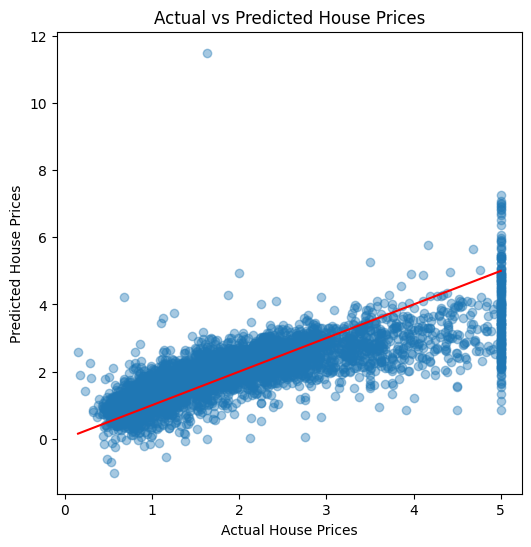

In [11]:
# Train your best performing model for visualization
best_model = LinearRegression() # Swap with Ridge() or DecisionTreeRegressor(max_depth=5) if preferred
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Generate the plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

# Draw the perfect prediction reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.show()